In [1]:
!pip -q install kagglehub opencv-python scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

/home/amber/Code/stat3106/Seeing-Clearly/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
dataset_path = kagglehub.dataset_download("msambare/fer2013")

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 60.3M/60.3M [00:07<00:00, 8.03MB/s]

Extracting files...


Dataset downloaded to:
/home/amber/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [5]:
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)

Train directory: /home/amber/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train
Test directory: /home/amber/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test


In [6]:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
train_dataset_full = ImageFolder(train_dir, transform=train_tf)
test_dataset = ImageFolder(test_dir, transform=eval_tf)

print("Training images:", len(train_dataset_full))
print("Test images:", len(test_dataset))

Training images: 28709
Test images: 7178


In [8]:
val_size = int(0.15 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size]
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 24403
Validation size: 4306


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [10]:
class_names = train_dataset_full.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


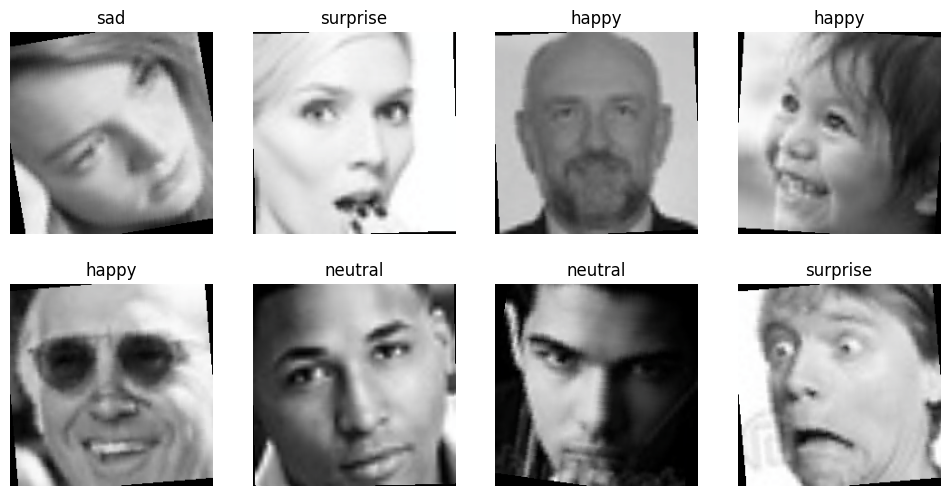

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,6))

for i in range(8):
    img = images[i].permute(1,2,0).numpy()

    # unnormalize
    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img = np.clip(img,0,1)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [12]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

print("Model ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/amber/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 10.8MB/s]


Model ready


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)

In [14]:
def train_epoch(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for i, (x, y) in enumerate(loader):

        if i % 50 == 0:
            print("Batch", i)

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [15]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [16]:
epochs = 5

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)
    print()

Batch 0
Batch 50
Batch 100
Batch 150
Batch 200
Batch 250
Batch 300
Batch 350
Batch 400
Batch 450
Batch 500
Batch 550
Batch 600
Batch 650
Batch 700
Batch 750
Batch 800
Batch 850
Batch 900
Batch 950
Batch 1000
Batch 1050
Batch 1100
Batch 1150
Batch 1200
Batch 1250
Batch 1300
Batch 1350
Batch 1400
Batch 1450
Batch 1500
Epoch 1
Train Loss: 1.8296866337249975
Train Accuracy: 0.24730565914026964
Validation Accuracy: 0.3313980492336275

Batch 0
Batch 50
Batch 100
Batch 150
Batch 200
Batch 250
Batch 300
Batch 350
Batch 400
Batch 450
Batch 500
Batch 550
Batch 600
Batch 650
Batch 700
Batch 750
Batch 800
Batch 850
Batch 900
Batch 950
Batch 1000
Batch 1050
Batch 1100
Batch 1150
Batch 1200
Batch 1250
Batch 1300
Batch 1350
Batch 1400
Batch 1450
Batch 1500
Epoch 2
Train Loss: 1.7105680609593072
Train Accuracy: 0.3072163258615744
Validation Accuracy: 0.36646539712029724

Batch 0
Batch 50
Batch 100
Batch 150
Batch 200
Batch 250
Batch 300
Batch 350
Batch 400
Batch 450
Batch 500
Batch 550
Batch 600
Batch

In [17]:
print(device)

cuda


In [18]:
torch.save(model.state_dict(), "fer_resnet18.pth")

print("Model saved.")

Model saved.


In [19]:
import cv2
import torch
import numpy as np
from PIL import Image

# Load saved model
model.load_state_dict(torch.load("fer_resnet18.pth", map_location=device))
model.eval()

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# transform for webcam images
infer_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

print("Press Q to quit")

while True:

    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(50,50)
    )

    for (x,y,w,h) in faces:

        face = frame[y:y+h, x:x+w]

        img = infer_tf(face).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img)
            probs = torch.softmax(outputs, dim=1)
            pred = torch.argmax(probs).item()
            conf = torch.max(probs).item()

        label = f"{class_names[pred]} ({conf:.2f})"

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

        cv2.putText(
            frame,
            label,
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

    cv2.imshow("Emotion Detector", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Press Q to quit
